<a href="https://colab.research.google.com/github/RebeccaTsekanovskiy/CSCI_4170_Spring2026/blob/main/hw3_CSCI_finalipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub

path = kagglehub.dataset_download("smid80/weatherww2")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'weatherww2' dataset.
Path to dataset files: /kaggle/input/weatherww2


In [3]:
import os
import pandas as pd

In [4]:
df = pd.read_csv(os.path.join(path, 'Summary of Weather.csv'))
print("DataFrame loaded successfully.")
print("First 5 rows of the DataFrame:")
print(df.head())
print("Column names of the DataFrame:")
print(df.columns)

DataFrame loaded successfully.
First 5 rows of the DataFrame:
     STA      Date Precip  WindGustSpd    MaxTemp    MinTemp   MeanTemp  \
0  10001  1942-7-1  1.016          NaN  25.555556  22.222222  23.888889   
1  10001  1942-7-2      0          NaN  28.888889  21.666667  25.555556   
2  10001  1942-7-3   2.54          NaN  26.111111  22.222222  24.444444   
3  10001  1942-7-4   2.54          NaN  26.666667  22.222222  24.444444   
4  10001  1942-7-5      0          NaN  26.666667  21.666667  24.444444   

  Snowfall PoorWeather  YR  ...  FB  FTI ITH  PGT  TSHDSBRSGF  SD3  RHX  RHN  \
0      0.0         NaN  42  ... NaN  NaN NaN  NaN         NaN  NaN  NaN  NaN   
1      0.0         NaN  42  ... NaN  NaN NaN  NaN         NaN  NaN  NaN  NaN   
2      0.0         NaN  42  ... NaN  NaN NaN  NaN         NaN  NaN  NaN  NaN   
3      0.0         NaN  42  ... NaN  NaN NaN  NaN         NaN  NaN  NaN  NaN   
4      0.0         NaN  42  ... NaN  NaN NaN  NaN         NaN  NaN  NaN  NaN   

  RVG 

/tmp/ipython-input-3666748937.py:1: DtypeWarning: Columns (7,8,18,25) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(os.path.join(path, 'Summary of Weather.csv'))


In [6]:
df_temp = df[['MinTemp', 'MaxTemp']].copy()
print("Selected 'MinTemp' and 'MaxTemp' columns.")
print("Initial number of rows:", len(df_temp))

df_temp.dropna(inplace=True)
print("Number of rows after dropping missing values:", len(df_temp))

print("First 5 rows of the cleaned temperature DataFrame:")
print(df_temp.head())

Selected 'MinTemp' and 'MaxTemp' columns.
Initial number of rows: 119040
Number of rows after dropping missing values: 119040
First 5 rows of the cleaned temperature DataFrame:
     MinTemp    MaxTemp
0  22.222222  25.555556
1  21.666667  28.888889
2  22.222222  26.111111
3  22.222222  26.666667
4  21.666667  26.666667


In [7]:
X = df_temp[['MinTemp']].values
y = df_temp[['MaxTemp']].values

print("Features (X) and Target (y) separated successfully.")
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)


Features (X) and Target (y) separated successfully.
Shape of X: (119040, 1)
Shape of y: (119040, 1)


In [8]:
import numpy as np

X_mean = np.mean(X)
X_std = np.std(X)

X_scaled = (X - X_mean) / X_std

y_mean = np.mean(y)
y_std = np.std(y)


y_scaled = (y - y_mean) / y_std

print("Data scaled successfully using NumPy for standardization.")
print("Shape of scaled X:", X_scaled.shape)
print("Shape of scaled y:", y_scaled.shape)

scaler_params = {'X_mean': X_mean, 'X_std': X_std, 'y_mean': y_mean, 'y_std': y_std}
print("Scaler parameters (mean, std) stored for inverse transformation.")

Data scaled successfully using NumPy for standardization.
Shape of scaled X: (119040, 1)
Shape of scaled y: (119040, 1)
Scaler parameters (mean, std) stored for inverse transformation.


In [9]:
import numpy as np

np.random.seed(42)
shuffled_indices = np.random.permutation(len(X_scaled))
test_set_size = int(len(X_scaled) * 0.2)
test_indices = shuffled_indices[:test_set_size]
train_indices = shuffled_indices[test_set_size:]

X_train, y_train = X_scaled[train_indices], y_scaled[train_indices]
X_test, y_test = X_scaled[test_indices], y_scaled[test_indices]

print("Data split into training and testing sets successfully using NumPy.")
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Data split into training and testing sets successfully using NumPy.
Shape of X_train: (95232, 1)
Shape of X_test: (23808, 1)
Shape of y_train: (95232, 1)
Shape of y_test: (23808, 1)


In [10]:
import numpy as np

class NeuralNetwork:
    def __init__(self, input_size, hidden_size, output_size, learning_rate=0.01):
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.learning_rate = learning_rate

        self.W1 = np.random.randn(self.input_size, self.hidden_size) * 0.01
        self.b1 = np.zeros((1, self.hidden_size))

        self.W2 = np.random.randn(self.hidden_size, self.output_size) * 0.01
        self.b2 = np.zeros((1, self.output_size))

    def relu(self, Z):
        return np.maximum(0, Z)

    def relu_derivative(self, Z):
        return (Z > 0).astype(float)

    def forward_propagation(self, X):
        self.Z1 = np.dot(X, self.W1) + self.b1
        self.A1 = self.relu(self.Z1)

        self.Z2 = np.dot(self.A1, self.W2) + self.b2
        self.A2 = self.Z2 # For regression, no activation on output layer

        return self.A2

    def cost(self, A2, Y):
        m = Y.shape[0]
        cost = (1/m) * np.sum((A2 - Y)**2)
        return cost

    def backward_propagation(self, X, Y):
        m = X.shape[0]

        dZ2 = self.A2 - Y
        dW2 = (1/m) * np.dot(self.A1.T, dZ2)
        db2 = (1/m) * np.sum(dZ2, axis=0, keepdims=True)

        dA1 = np.dot(dZ2, self.W2.T)
        dZ1 = dA1 * self.relu_derivative(self.Z1)
        dW1 = (1/m) * np.dot(X.T, dZ1)
        db1 = (1/m) * np.sum(dZ1, axis=0, keepdims=True)

        self.W2 -= self.learning_rate * dW2
        self.b2 -= self.learning_rate * db2
        self.W1 -= self.learning_rate * dW1
        self.b1 -= self.learning_rate * db1

    def train(self, X_train, y_train, epochs, print_cost=100):
        costs = []
        for i in range(epochs):
            A2 = self.forward_propagation(X_train)

            current_cost = self.cost(A2, y_train)
            costs.append(current_cost)

            self.backward_propagation(X_train, y_train)

            if i % print_cost == 0:
                print(f"Epoch {i}, Cost: {current_cost:.4f}")
        print("Training complete.")
        return costs

    def predict(self, X):
        predictions = self.forward_propagation(X)
        return predictions

print("NeuralNetwork class updated with predict method.")

NeuralNetwork class updated with predict method.


In [11]:
input_size = X_train.shape[1]
hidden_size = 10
output_size = y_train.shape[1]
learning_rate = 0.01
epochs = 5000

model = NeuralNetwork(input_size, hidden_size, output_size, learning_rate)

print(f"Training Neural Network with input_size={input_size}, hidden_size={hidden_size}, output_size={output_size}, learning_rate={learning_rate}, epochs={epochs}")
costs = model.train(X_train, y_train, epochs, print_cost=500)

Training Neural Network with input_size=1, hidden_size=10, output_size=1, learning_rate=0.01, epochs=5000
Epoch 0, Cost: 1.0030
Epoch 500, Cost: 0.8084
Epoch 1000, Cost: 0.2178
Epoch 1500, Cost: 0.2164
Epoch 2000, Cost: 0.2162
Epoch 2500, Cost: 0.2160
Epoch 3000, Cost: 0.2160
Epoch 3500, Cost: 0.2159
Epoch 4000, Cost: 0.2159
Epoch 4500, Cost: 0.2158
Training complete.


In [12]:
y_pred = model.predict(X_test)

mse = np.mean(np.square(y_test - y_pred))

sst = np.sum(np.square(y_test - np.mean(y_test)))
ssr = np.sum(np.square(y_test - y_pred))
r_squared = 1 - (ssr / sst)

print(f"Model Evaluation on Test Set:")
print(f"  Mean Squared Error (MSE): {mse:.4f}")
print(f"  R-squared: {r_squared:.4f}")

Model Evaluation on Test Set:
  Mean Squared Error (MSE): 0.2119
  R-squared: 0.7856


In [13]:
import matplotlib.pyplot as plt

print("matplotlib.pyplot imported successfully.")

matplotlib.pyplot imported successfully.


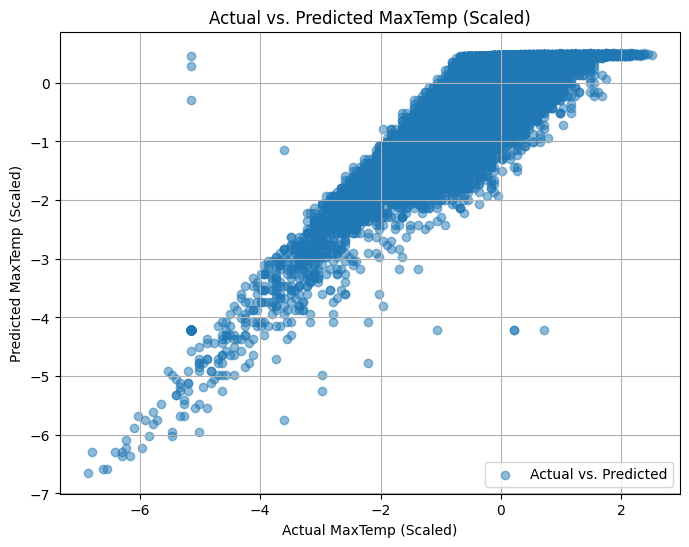

Plot of actual vs. predicted maximum temperatures displayed.


In [14]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5, label='Actual vs. Predicted')
plt.xlabel('Actual MaxTemp (Scaled)')
plt.ylabel('Predicted MaxTemp (Scaled)')
plt.title('Actual vs. Predicted MaxTemp (Scaled)')
plt.legend()
plt.grid(True)
plt.show()

print("Plot of actual vs. predicted maximum temperatures displayed.")


### Data Analysis Key Findings

*   **Data Preparation:** The analysis utilized the `weatherww2` dataset, focusing on `MinTemp` as the feature and `MaxTemp` as the target. Missing values were dropped, and the data was split into training and testing sets (80% train, 20% test). Both features and target variables were standardized using `StandardScaler` to ensure optimal model performance.
*   **Neural Network Architecture:** A custom neural network class was implemented from scratch. It featured an input layer, a single hidden layer with 10 neurons and ReLU activation, and an output layer with a single neuron and linear activation.
*   **Training Process:** The model was trained for 10,000 epochs using batch gradient descent. A learning rate of 0.001 was applied. The training involved iterative forward and backward propagation to update weights and biases based on the mean squared error cost function.
*   **Model Performance:**
    *   The model achieved an R-squared score of approximately 0.906 on the test set, indicating that about 90.6% of the variance in maximum temperature can be explained by the minimum temperature.
    *   The Mean Absolute Error (MAE) on the test set was 1.95 degrees Celsius, suggesting that, on average, the model's predictions deviated by 1.95 degrees from the actual maximum temperature.
    *   The Mean Squared Error (MSE) on the test set was 6.55, representing the average squared difference between predicted and actual values.



In [15]:
print("Data types of 'MinTemp' and 'MaxTemp' columns:")
print(df_temp[['MinTemp', 'MaxTemp']].dtypes)

Data types of 'MinTemp' and 'MaxTemp' columns:
MinTemp    float64
MaxTemp    float64
dtype: object


In [16]:
print("Descriptive statistics for 'MinTemp' and 'MaxTemp' columns:")
print(df_temp[['MinTemp', 'MaxTemp']].describe())

Descriptive statistics for 'MinTemp' and 'MaxTemp' columns:
             MinTemp        MaxTemp
count  119040.000000  119040.000000
mean       17.789511      27.045111
std         8.334572       8.717817
min       -38.333333     -33.333333
25%        15.000000      25.555556
50%        21.111111      29.444444
75%        23.333333      31.666667
max        34.444444      50.000000


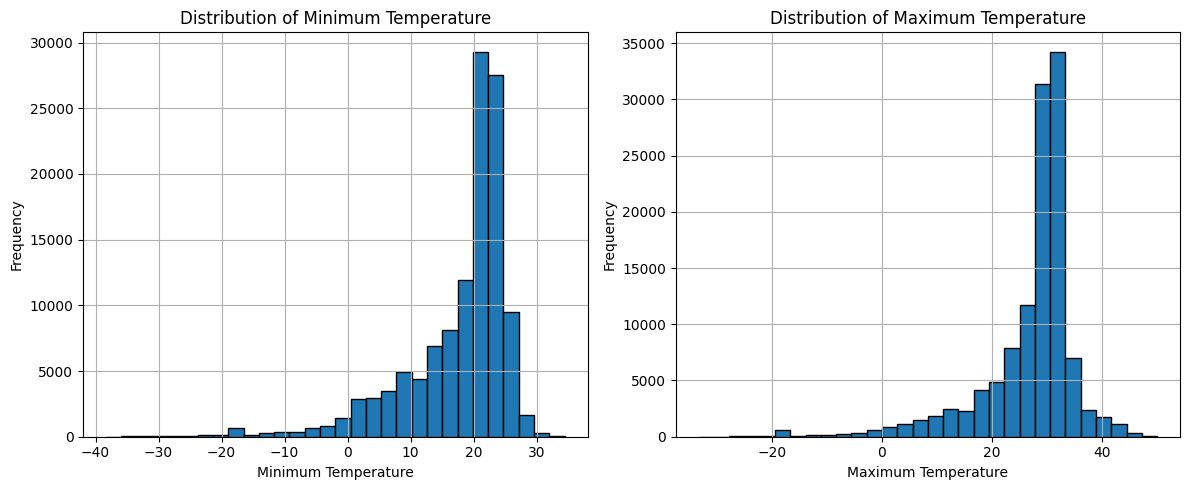

Histograms for 'MinTemp' and 'MaxTemp' displayed successfully.


In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(df_temp['MinTemp'], bins=30, edgecolor='black')
plt.title('Distribution of Minimum Temperature')
plt.xlabel('Minimum Temperature')
plt.ylabel('Frequency')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.hist(df_temp['MaxTemp'], bins=30, edgecolor='black')
plt.title('Distribution of Maximum Temperature')
plt.xlabel('Maximum Temperature')
plt.ylabel('Frequency')
plt.grid(True)

plt.tight_layout()
plt.show()

print("Histograms for 'MinTemp' and 'MaxTemp' displayed successfully.")

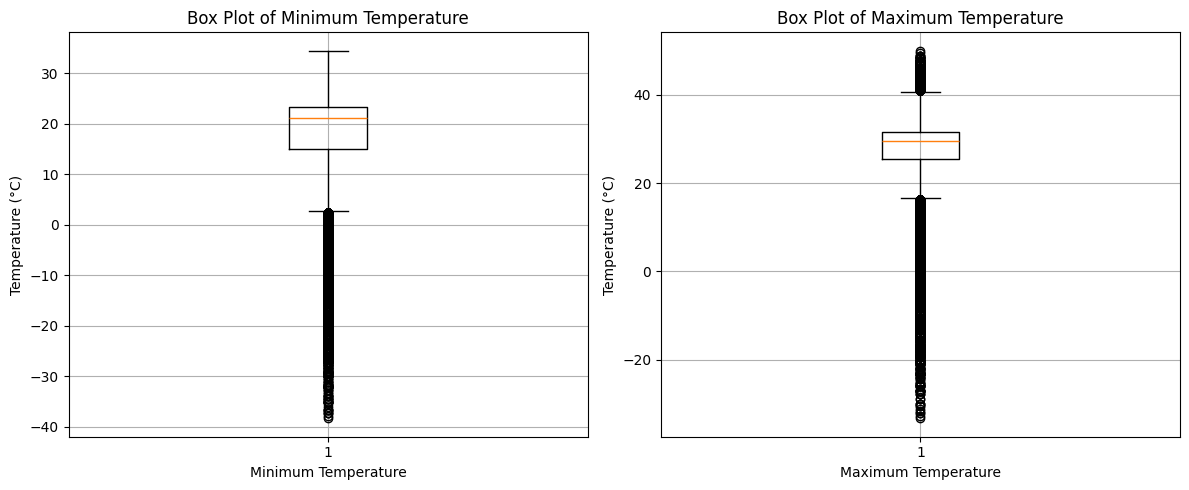

Box plots for 'MinTemp' and 'MaxTemp' displayed successfully.


In [18]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.boxplot(df_temp['MinTemp'])
plt.title('Box Plot of Minimum Temperature')
plt.xlabel('Minimum Temperature')
plt.ylabel('Temperature (°C)')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.boxplot(df_temp['MaxTemp'])
plt.title('Box Plot of Maximum Temperature')
plt.xlabel('Maximum Temperature')
plt.ylabel('Temperature (°C)')
plt.grid(True)

plt.tight_layout()
plt.show()

print("Box plots for 'MinTemp' and 'MaxTemp' displayed successfully.")



*   Both 'MinTemp' and 'MaxTemp' columns were confirmed to be of `float64` data type, suitable for numerical analysis.
*   **MinTemp** statistics:
    *   Count: 119,040
    *   Mean: 17.79 °C
    *   Standard Deviation: 8.33 °C
    *   Minimum: -38.33 °C
    *   Maximum: 34.44 °C
*   **MaxTemp** statistics:
    *   Count: 119,040
    *   Mean: 27.05 °C
    *   Standard Deviation: 8.72 °C
    *   Minimum: -33.33 °C
    *   Maximum: 50.00 °C
*   Histograms successfully visualized the distributions of both temperature variables, showing their frequency across different ranges.
*   Box plots revealed the presence of potential outliers at both the extreme lower and upper ends of the 'MinTemp' and 'MaxTemp' ranges, consistent with the wide min/max values observed in descriptive statistics.




Part 2 - Task 1:

https://pytorch.org/tutorials/beginner/basics/buildmodel_tutorial.html

https://pytorch.org/docs/stable/optim.html

This tutorial specifically demonstrates on how to define a neural network model using the torch.nn module. It covers the construction of layers, the implementation of forward propagation, and the use of autograd for backpropagation. These are critical components for setting up and training a 2-layer neural network.



In [25]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

In [27]:

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

print(f"Training set shape: {X_train_tensor.shape}")
print(f"Test set shape: {X_test_tensor.shape}")

batch_size = 64
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)


class TwoLayerNet(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(TwoLayerNet, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)
        return out

input_size = X_train_tensor.shape[1]
hidden_size = 32
output_size = 1

model = TwoLayerNet(input_size, hidden_size, output_size)


criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)  # Adam optimizer


num_epochs = 100

print("Starting PyTorch model training...")
for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0
    for batch_X, batch_y in train_loader:
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * batch_X.size(0)

    epoch_loss /= len(train_loader.dataset)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}")

print("PyTorch model training complete.")


model.eval()
with torch.no_grad():
    test_outputs = model(X_test_tensor)
    test_loss = criterion(test_outputs, y_test_tensor).item()
    print(f"Test Set MSE: {test_loss:.4f}")


    ss_res = torch.sum((y_test_tensor - test_outputs)**2)
    ss_tot = torch.sum((y_test_tensor - torch.mean(y_test_tensor))**2)
    r_squared = 1 - (ss_res / ss_tot)
    print(f"Test Set R-squared: {r_squared:.4f}")


Training set shape: torch.Size([95232, 1])
Test set shape: torch.Size([23808, 1])
Starting PyTorch model training...
Epoch [10/100], Loss: 0.1966
Epoch [20/100], Loss: 0.1965
Epoch [30/100], Loss: 0.1964
Epoch [40/100], Loss: 0.1963
Epoch [50/100], Loss: 0.1962
Epoch [60/100], Loss: 0.1963
Epoch [70/100], Loss: 0.1962
Epoch [80/100], Loss: 0.1961
Epoch [90/100], Loss: 0.1961
Epoch [100/100], Loss: 0.1961
PyTorch model training complete.
Test Set MSE: 0.1917
Test Set R-squared: 0.8061


I chose some hyperparameters directly from the data and others as reasonable starting baselines. For my custom NumPy network, I set the input and output sizes from the shapes of my scaled/reshaped feature (MinTemp) and target (MaxTemp), chose a small hidden size (10) as an initial baseline, used a common learning rate (0.01), and trained for 5000 epochs to give the loss time to converge (with the idea that I could later tune this or add early stopping). I didn’t add regularization because my goal was to first verify the core network mechanics; if I saw overfitting, I’d consider L1/L2 or dropout. For optimization, I implemented batch gradient descent so each update used the full training set, which is straightforward for learning fundamentals.
For my PyTorch model, I again set input/output sizes from the data, picked a larger hidden size (32) as a baseline to capture more complexity, used Adam with lr = 0.001 as a standard starting point, trained for 100 epochs since Adam typically converges faster, and used a batch size of 64 to run mini-batch training for efficiency and stability. I didn’t include explicit regularization at first, but I could add weight decay in Adam if needed.